# Task 2: Original LCS System on Raw Dataset

## Imports

In [106]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy.stats import chi2_contingency
from skeLCS import eLCS
import time
import re



## Loading Dataset: Using Pandas

Loading the raw dataset without any preprocessing. This is not yet suitable for an LCS baseline. 

In [107]:
# Read from CSV file
data = pd.read_csv("/Users/christian/Uni_Files/2026/Semester 2/Data Engineering and AI/Data-Engineering-and-AI-Project-Phase-1/Phase-I/PhiUSIIL_Phishing_URL_Dataset.csv")

# Specify the dataset's phenotype label
classLabel = "label"

# Derive the attributes and phenotype array using the phenotype label
dataFeatures = data.drop(classLabel, axis= 1).values
dataPhenotypes = data[classLabel].values

dataHeaders = data.drop(classLabel, axis=1).columns.values

print("Data Features")
print(dataFeatures)
print("Data Phenotypes")
print(dataPhenotypes)
print("Data Headers")
print(dataHeaders)

Data Features
[['521848.txt' 'https://www.southbankmosaics.com' 31 ... 119 0 124]
 ['31372.txt' 'https://www.uni-mainz.de' 23 ... 39 0 217]
 ['597387.txt' 'https://www.voicefmradio.co.uk' 29 ... 42 2 5]
 ...
 ['622132.txt' 'https://www.nononsensedesign.be' 30 ... 58 2 67]
 ['7503962.txt'
  'https://patient-cell-40f5.updatedlogmylogin.workers.dev/' 55 ... 0 0 0]
 ['384822.txt' 'https://www.alternativefinland.com' 33 ... 256 0 261]]
Data Phenotypes
[1 1 1 ... 1 0 1]
Data Headers
<StringArray>
[                  'FILENAME',                        'URL',
                  'URLLength',                     'Domain',
               'DomainLength',                 'IsDomainIP',
                        'TLD',         'URLSimilarityIndex',
       'CharContinuationRate',          'TLDLegitimateProb',
                'URLCharProb',                  'TLDLength',
              'NoOfSubDomain',             'HasObfuscation',
         'NoOfObfuscatedChar',           'ObfuscationRatio',
           'NoOf

## Minimal Processed Dataset

- Dropped four features such as FILENAME, URL, Domain, and Title as LCS code requires numeric, can't consume a text.

In [108]:
# Dropping features that is not suitable for LCS baseline
dropped_features = ["FILENAME", "URL", "Domain", "TLD", "Title", "label"]
classLabel = data["label"]

# All features that the model can use for training in making predictions
X = data.drop(columns=dropped_features) 
# The actual target that the model trying to predict
y = classLabel

X.head(10)

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef
0,31,24,0,100.0,1.000000,0.522907,0.061933,3,1,0,...,1,0,0,1,34,20,28,119,0,124
1,23,16,0,100.0,0.666667,0.032650,0.050207,2,1,0,...,0,0,0,1,50,9,8,39,0,217
2,29,22,0,100.0,0.866667,0.028555,0.064129,2,2,0,...,0,0,0,1,10,2,7,42,2,5
3,26,19,0,100.0,1.000000,0.522907,0.057606,3,1,0,...,0,1,1,1,3,27,15,22,1,31
4,33,26,0,100.0,1.000000,0.079963,0.059441,3,1,0,...,1,1,0,1,244,15,34,72,1,85
5,30,23,0,100.0,1.000000,0.079963,0.060614,3,1,0,...,0,0,0,1,35,1,11,86,0,14
6,25,18,0,100.0,1.000000,0.522907,0.063549,3,1,0,...,0,0,0,1,32,4,14,44,2,17
7,25,18,0,100.0,1.000000,0.522907,0.060486,3,1,0,...,0,0,0,1,24,2,22,36,0,15
8,29,22,0,100.0,1.000000,0.005084,0.056980,2,1,0,...,0,0,0,1,71,4,9,40,1,317
9,18,11,0,100.0,1.000000,0.079963,0.070497,3,1,0,...,0,0,0,1,10,1,12,173,6,65


## Stratified subsample

- Stratified subsample for the data split which aims to preserves the same class distribution as the full dataset.

In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set: {X_train.shape}, Phishing cases: {(y_train == 0).sum()}")
print(f"Test set: {X_test.shape}, Phishing cases: {(y_test == 0).sum()}")
print(f"Training set: {X_train.shape}, Legitimate cases: {(y_train == 1).sum()}")
print(f"Test set: {X_test.shape}, Legitimate cases: {(y_test == 1).sum()}")

Training set: (188636, 50), Phishing cases: 80756
Test set: (47159, 50), Phishing cases: 20189
Training set: (188636, 50), Legitimate cases: 107880
Test set: (47159, 50), Legitimate cases: 26970


- Using the raw data with minimal preprocessing and using a 80/20 data split
- The proportion of legitimate and phishing URLs reflects on what is result of class distribution from Phase-I

## Run the original LCS without any modification

In [110]:
# Initialize eLCS model
model = eLCS(learning_iterations=10000, random_state=42)

# Initiate a start time on how long does the training last.
start = time.time()
model.fit(X_train.to_numpy(), y_train.to_numpy())
elapsed = time.time() - start

prediction = model.predict(X_test.to_numpy())

print(f"Training time: {elapsed:.2f} seconds")
print(f"Accuracy Score: {accuracy_score(y_test, prediction):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, prediction):.4f}")
print(f"Precision Score: {precision_score(y_test, prediction, pos_label=1, zero_division=0):.4f}")
print(f"Recall {recall_score(y_test, prediction, pos_label=1, zero_division=0):.4f}")
print(f"F1 Score: {f1_score(y_test, prediction, pos_label=1, zero_division=0):.4f}")
print(f"Precision Score: {precision_score(y_test, prediction, pos_label=0, zero_division=0):.4f}")
print(f"Recall {recall_score(y_test, prediction, pos_label=0, zero_division=0):.4f}")
print(f"F1 Score: {f1_score(y_test, prediction, pos_label=0, zero_division=0):.4f}")
print(confusion_matrix(y_test, prediction, labels=[0, 1]))


Training time: 18.90 seconds
Accuracy Score: 0.9990
Balanced Accuracy: 0.9989
Precision Score: 0.9983
Recall 1.0000
F1 Score: 0.9992
Precision Score: 1.0000
Recall 0.9978
F1 Score: 0.9989
[[20144    45]
 [    0 26970]]


# Task 3 Data Preprocessing and Feature Engineering

- From Phase-I and derived from the actual description of the original authors there is no missing values across the dataset.
- But there are inconsistencies within the dataset which was also addressed in Phase-I.
- But because i'm using the original raw dataset from Phase-I, I would start again to avoid any data-leakage

In [111]:
# Start from the raw dataset without dropping any features yet, to addressed any data issues first before any test split
data_lcs = pd.read_csv("/Users/christian/Uni_Files/2026/Semester 2/Data Engineering and AI/Data-Engineering-and-AI-Project-Phase-1/Phase-I/PhiUSIIL_Phishing_URL_Dataset.csv")
# Create a copy of the dataset to preserve the original one.
data_lcs_copy = data_lcs.copy()

# Addressing any missing values
print("\n--- 1. Missing Values ---")
missing = data_lcs_copy.isnull().sum().sum()
print(f"Total missing cells: {missing}")

if missing > 0:
    raise ValueError(
        "Missing values detected."
        "Add an explicit imputation strategy before proceeding."
    )
print("No action needed - dataset has no missing values.\n")

# Addressing URL duplicated records
print("\n--- 2. Duplicated records ---")
before = len(data_lcs_copy)
dup_url_count = data_lcs_copy["URL"].duplicated().sum()
print(f"Duplicate URL values before dedup: {dup_url_count}")

# Drop duplicated records using copy
drop_url_dup = data_lcs_copy.drop_duplicates(subset="URL", keep="first").reset_index(drop=True)
print(f"Rows removed : {before - len(drop_url_dup)}")
print(f"Rows remaining : {len(drop_url_dup):,}\n")


# Addressing invalid values
print("\n--- 3. Invalid values [IsHTTPS and IsDomainIP] ---")

# IsHTTPS: recompute from the actual URL schemed prefix, not the stored flag
before_https_mismatch = (
    (drop_url_dup["IsHTTPS"] == 1) & (~drop_url_dup["URL"].str.startswith("https://"))
).sum()
drop_url_dup["IsHTTPS"] = drop_url_dup["URL"].str.startswith("https://").astype(int)
print(f"IsHTTPS corrected on {before_https_mismatch} rows "
      f"(recomputed from URL scheme prefix). ")

# IsDomainIP: recompute from a strict IPv4 pattern match on Domain
ip_pattern = re.compile(r"^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$")
is_bare_ip = drop_url_dup["Domain"].astype(str).str.match(ip_pattern)
before_ip_mismatch = ((drop_url_dup["IsDomainIP"] == 1) & (~is_bare_ip)).sum()
drop_url_dup["IsDomainIP"] = is_bare_ip.astype(int)
print(f"IsDomainIP corrected on {before_ip_mismatch} rows "
      f"(recomputed from strict IPv4 pattern match on Domain).\n")

# Addressing inconsistent categories and formatting issues
print("\n--- 4. Inconsistent categories & formatting ---")

# Title: the placeholder string "0" only appears when HasTitle=0 and does
# not represents a real page title, so it is cleared to an empty string
placeholder_count = (
    (drop_url_dup["HasTitle"] == 0) & (drop_url_dup["Title"] == "0")
).sum()
drop_url_dup.loc[
    (drop_url_dup["HasTitle"] == 0) & (drop_url_dup["Title"] == "0"), "Title"
] = np.nan
print(f"Title placeholder '0' cleared to NaN on {placeholder_count} rows.")

# Title: strip stray whitespace; TLD: standardise casing to lowercase
drop_url_dup["Title"] = drop_url_dup["Title"].astype(str).str.strip()
drop_url_dup["TLD"] = drop_url_dup["TLD"].astype(str).str.lower()
print("Title whitespace stripped; TLD standardised to lowercase.\n")

# Fixing incorrect / inefficient data types
print("\n--- 5. Data type fixes ---")
binary_cols = [
    "IsDomainIP", "HasObfuscation", "IsHTTPS", "HasTitle", "HasFavicon",
    "Robots", "IsResponsive", "HasDescription", "HasExternalFormSubmit",
    "HasSocialNet", "HasSubmitButton", "HasHiddenFields",
    "HasPasswordField", "Bank", "Pay", "Crypto", "HasCopyrightInfo",
    "label",
]
for col in binary_cols:
    drop_url_dup[col] = drop_url_dup[col].astype("int8")
drop_url_dup["TLD"] = drop_url_dup["TLD"].astype("category")
print(f"Cast {len(binary_cols)} binary columns to int8; TLD to category dtype.\n")

print("\n--- 6. log1p transformations ---")

# Heavily right-skewed count/size columns identified in Phase 1
skewed_cols = [
    "URLLength", "LineOfCode", "LargestLineLength", "NoOfImage", "NoOfCSS",
    "NoOfJS", "NoOfSelfRef", "NoOfEmptyRef", "NoOfExternalRef",
]

# Safety check: log1p requires values greater than -1
assert (drop_url_dup[skewed_cols] >= 0).all().all(), "Negative values found, log1p not safe"

# Create a _log version of each column, keeping the originals for now
for col in skewed_cols:
    drop_url_dup[f"{col}_log"] = np.log1p(drop_url_dup[col])

print(f"Added log1p columns for {len(skewed_cols)} features")

# Verify: compare the spread before and after
comparison = pd.DataFrame({
    "original_max": drop_url_dup[skewed_cols].max().values,
    "log_max": drop_url_dup[[f"{c}_log" for c in skewed_cols]].max().values,
    "original_skew": drop_url_dup[skewed_cols].skew().values,
    "log_skew": drop_url_dup[[f"{c}_log" for c in skewed_cols]].skew().values,
}, index=skewed_cols).round(3)

print(comparison)



--- 1. Missing Values ---
Total missing cells: 0
No action needed - dataset has no missing values.


--- 2. Duplicated records ---
Duplicate URL values before dedup: 425
Rows removed : 425
Rows remaining : 235,370


--- 3. Invalid values [IsHTTPS and IsDomainIP] ---
IsHTTPS corrected on 493 rows (recomputed from URL scheme prefix). 
IsDomainIP corrected on 39 rows (recomputed from strict IPv4 pattern match on Domain).


--- 4. Inconsistent categories & formatting ---
Title placeholder '0' cleared to NaN on 32612 rows.
Title whitespace stripped; TLD standardised to lowercase.


--- 5. Data type fixes ---
Cast 18 binary columns to int8; TLD to category dtype.


--- 6. log1p transformations ---
Added log1p columns for 9 features
                   original_max  log_max  original_skew  log_skew
URLLength                  6097    8.716         53.347     2.299
LineOfCode               442666   13.001         53.037    -0.476
LargestLineLength      13975732   16.453         47.851     0.106

- Create a copy of the raw dataset, so that the original one is preserved 
- Deriving from the Phase-I there are no missing values across the dataset. But still verified it by checking nulls in every single rows
- Drop 425 duplicated records from URL
- Cross check IsHTTPS with the actual URL scheme prefix and corrected 493 rows
- recomputed IsDomainIP on a strict IPv4 pattern match on Domain and corrected 39 rows
- Addressing inconsistent categories and formatting
- Cast 18 binary columns to int 8 and TLD to category dtype
- Using log1p I transform skewed columns that has been identified from Phase-I, and added a new 9 features derived from the skewed_cols.

## Stratified Train/Test Split

- All data issues that has been identified from Phase-I has been readdressed in Phase-II before any data split, this make sure that no information from the test set influences preprocessing decisions. 
- Also transforming log1p was necessary as this prevents data leakage as it only transforms its own values. So there are no other way to leak any data or any information.

In [112]:
# Separate the target from everything else
target = drop_url_dup["label"]
features = drop_url_dup.drop(columns=["label"])

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, stratify=target, random_state=42
)

print(f"Training set: {X_train.shape}, Phishing Case: {(y_train == 0).sum()}")
print(f"Test set: {X_test.shape}, Phishing Case: {(y_test == 0).sum()}")


Training set: (188296, 64), Phishing Case: 80416
Test set: (47074, 64), Phishing Case: 20104


## Dropping identifier / text columns from X_train and X_test

- After cleansing and address every data issues it is safe to drop this columns FILENAME, URL, Domain, and Title.
- This dropping identifier is not considered as predictor it is just needed to be used for proper addressing data issues and transformation.

In [113]:
# Dropping identifier features
identifier_features = ["FILENAME", "URL", "Domain", "TLD", "Title"]

# Keeping URLs aside so any row can still be traced back later
train_urls = X_train["URL"]
test_urls = X_test["URL"]

X_train = X_train.drop(columns=(identifier_features))
X_test = X_test.drop(columns=(identifier_features))

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# 1. Train and test must have exactly the same columns, in the same order
assert list(X_train.columns) == list(X_test.columns), "Train/test columns differ"

# 2. No text columns should remain, since eLCS needs fully numeric input
non_numeric = X_train.select_dtypes(exclude="number").columns.tolist()
print("Non-numeric columns remaining:", non_numeric)   # should print []

# 3. None of the identifiers should still be present
print("Identifiers remaining:", [c for c in identifier_features if c in X_train.columns])   # should print []

Training set: (188296, 59)
Test set: (47074, 59)
Non-numeric columns remaining: []
Identifiers remaining: []


## Outlier Investigation in Training Set Only

 - Outliers can be either errors or genuine information. This reveals what kind of extremes that the dataset have, either a very large website with thousand lines of code or just a a typo, or a broken scrape, or an impossible value like a negative page count.
 

In [114]:
# Outlier Investigation

overall_legit = (y_train == 1).mean()
results = []

for col in skewed_cols:
    q1, q3 = X_train[col].quantile([0.25, 0.75])
    upper = q3 + 1.5 * (q3 - q1)
    is_outlier = X_train[col] > upper

    table = pd.crosstab(is_outlier, y_train)
    chi2, p, _, _ = chi2_contingency(table)

    results.append({
        "feature": col,
        "upper_fence": round(upper, 2),
        "outlier_%": round(is_outlier.mean() * 100, 2),
        "legit_share_in_outliers": round((y_train[is_outlier] == 1).mean(), 4),
        "overall_legit_share": round(overall_legit, 4),
        "chi2_p_value": p,
    })

outlier_summary = pd.DataFrame(results)
print(outlier_summary)

             feature  upper_fence  outlier_%  legit_share_in_outliers  \
0          URLLength         50.5       9.55                   0.0005   
1         LineOfCode       3170.5       8.16                   0.9975   
2  LargestLineLength      19817.5       7.40                   0.6071   
3          NoOfImage         72.5       7.80                   0.9998   
4            NoOfCSS         20.0       7.61                   0.9979   
5             NoOfJS         37.5       5.01                   0.9860   
6        NoOfSelfRef        220.0       6.63                   1.0000   
7       NoOfEmptyRef          2.5      16.52                   0.9698   
8    NoOfExternalRef        141.0       9.66                   0.9998   

   overall_legit_share  chi2_p_value  
0               0.5729  0.000000e+00  
1               0.5729  0.000000e+00  
2               0.5729  2.707740e-17  
3               0.5729  0.000000e+00  
4               0.5729  0.000000e+00  
5               0.5729  0.000000e+0

- Based on this investigation mostly the outliers are entirely legitimate an extreme high values from these features comes from legitimate sites. This matches what we find out in Phase-I.
- URLLength is the only feature the runs the opposite which sits at 0.005%, means that 0.0005% of its outliers are legitimate which says that unusual long URLs are always phishing. 
- LargestLineLength sits at 0.6071 which is very close to 0.5729 which means the its outliers are fairly mixed combinations of classes. So there's not much information to dig into.


## Dropping original features the from the skewed features

In [129]:
# Dropped skewed columns from only the X_train and X_test
X_train_pr = X_train.drop(columns=skewed_cols)
X_test_pr = X_test.drop(columns=skewed_cols)

print(X_train_pr.shape)
print(X_test_pr.shape)

(188296, 50)
(47074, 50)


## Scaling Continous Features

In [117]:
ranges = X_train_pr.agg(["min", "max"]).T
ranges["range"] = ranges["max"] - ranges["min"]
print(ranges.sort_values("range", ascending=False))

                                 min          max        range
NoOfLettersInURL            0.000000  5191.000000  5191.000000
NoOfDegitsInURL             0.000000  2011.000000  2011.000000
NoOfiFrame                  0.000000  1602.000000  1602.000000
NoOfPopup                   0.000000   602.000000   602.000000
NoOfOtherSpecialCharsInURL  0.000000   499.000000   499.000000
NoOfObfuscatedChar          0.000000   447.000000   447.000000
NoOfEqualsInURL             0.000000   176.000000   176.000000
NoOfAmpersandInURL          0.000000   149.000000   149.000000
DomainLength                4.000000   110.000000   106.000000
URLTitleMatchScore          0.000000   100.000000   100.000000
DomainTitleMatchScore       0.000000   100.000000   100.000000
URLSimilarityIndex          0.155574   100.000000    99.844426
LargestLineLength_log       3.178054    16.452833    13.274779
LineOfCode_log              1.098612    13.000573    11.901961
TLDLength                   2.000000    13.000000    11

- 17 features from the dataset is binary flags which means its value is either 0 and 1, but 2 more features behaves as binary flags though its name (NoOfURLRedirect & NoOfSelfRedirect) seems they are counts but their values contains only 0 and 1. I just treat them as binary features instead of discrete or continuous features. Total of 19 binary features.
- There are a 31 Non-binary features in the dataset.
- I test ranges from the whole features to check on any extremes that can be scaled. I've tried scaling the whole feature which is not a good idea s 19 of the features are in binary which means scaling it would be very awkward as binary features that are set by the original authors will not be binary anymore as StandardScaler computes its feature as (value - column mean) / column standard deviation so 0 turns to -0.05 and 1 turns about 21.8 which will the eLCS will treat them as discrete and it add nothing as it is already flags on small comparable 0 to 1 range.
- I've tried different techniques such as scaling only the non-binary features and also the one is transforming extremes values using log1p same thing i did with the 9 features. The unscaled version of the dataset is still has the most significant result based on accuracy. 

## Class Imbalance

In [118]:
print("\n--- Class Imbalance Check (Training Set) ---")

counts = y_train.value_counts().sort_index()
props  = y_train.value_counts(normalize=True).sort_index()

print(pd.DataFrame({"count": counts, "proportion": props.round(4)},
                   index=[0, 1]).rename(index={0: "Phishing", 1: "Legitimate"}))
print(f"Imbalance ratio (legitimate:phishing): {counts[1] / counts[0]:.2f} : 1")


--- Class Imbalance Check (Training Set) ---
             count  proportion
Phishing     80416      0.4271
Legitimate  107880      0.5729
Imbalance ratio (legitimate:phishing): 1.34 : 1


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

def summarise(y_true, y_pred):
    return {
        "Accuracy":             accuracy_score(y_true, y_pred),
        "Balanced Accuracy":    balanced_accuracy_score(y_true, y_pred),
        "Precision (Phishing)": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Recall (Phishing)":    recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Recall (Legitimate)":  recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "F1 (Phishing)":        f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Missed phishing (FN)": int(((y_true == 0) & (y_pred == 1)).sum()),
        "False alarms (FP)":    int(((y_true == 1) & (y_pred == 0)).sum()),
    }

# Train eLCS on original and resampled training data
X_test_np = X_test.to_numpy(dtype=float)
y_test_np = y_test.to_numpy(dtype=int)

training_sets = {
    "Original": (X_train_pr, y_train),
    "Undersampled": RandomUnderSampler(random_state=42).fit_resample(X_train_pr, y_train),
    "Oversampled":  RandomOverSampler(random_state=42).fit_resample(X_train_pr, y_train),
}

results, train_times = {}, {}

for name, (X_tr, y_tr) in training_sets.items():
    print(f"\n{name}: {X_tr.shape[0]:,} rows, class counts {y_tr.value_counts().sort_index().to_dict()}")

    model = eLCS(learning_iterations=10000, random_state=42)
    start = time.time()
    model.fit(X_tr.to_numpy(dtype=float), y_tr.to_numpy(dtype=int))
    train_times[name] = time.time() - start

    prediction = model.predict(X_test_np)        # same untouched test set every time
    results[name] = summarise(y_test_np, prediction)
    print(confusion_matrix(y_test_np, prediction, labels=[0, 1]))

# Comparison
comparison = pd.DataFrame(results).round(4)
comparison.loc["Training time (s)"] = pd.Series(train_times).round(2)
print("\n--- Class Imbalance Comparison ---")
print(comparison)


Original: 188,296 rows, class counts {0: 80416, 1: 107880}
[[20074    30]
 [   23 26947]]

Undersampled: 160,832 rows, class counts {0: 80416, 1: 80416}
[[20050    54]
 [   22 26948]]

Oversampled: 215,760 rows, class counts {0: 107880, 1: 107880}
[[20057    47]
 [   10 26960]]

--- Class Imbalance Comparison ---
                      Original  Undersampled  Oversampled
Accuracy                0.9989        0.9984       0.9988
Balanced Accuracy       0.9988        0.9982       0.9986
Precision (Phishing)    0.9989        0.9989       0.9995
Recall (Phishing)       0.9985        0.9973       0.9977
Recall (Legitimate)     0.9991        0.9992       0.9996
F1 (Phishing)           0.9987        0.9981       0.9986
Missed phishing (FN)   30.0000       54.0000      47.0000
False alarms (FP)      23.0000       22.0000      10.0000
Training time (s)      18.2000       15.9200      19.6600


- The imbalance is already mild which has been identified from Phase-I, addressing the imbalance using RandomUnderSample and RandomOverSample comparing to its original training data. It is clearly that it is not relevant in this dataset to do a resampling because comparing the accuracy score of each three samples there are small differences which does not add any information though oversampling mainly changed the false alarms to 10 but oversampling which makes the it duplicate the existing phishing rows which does not add new information rather it only duplicates records that eLCS treats it as same rather than treating as a new example.
- In terms of what matters in a phishing detector though the results is somehow counterintuitive it's much better to stick on the original dataset as oversampling missed 47 phishing attacks while original dataset had 30, though in terms of cybersecurity having a 47 missed phishing is generally treated and considered as dangerous.
- This evidence supports on why I am keeping and sticking in the original data the trades off are way to big if we are talking about of a developing a phishing detector original has more precision than using the other sampling

## Feature Engineering and Feature Selection where it is relevant

 - Check features that has a high percentage information with the label. 

In [119]:
import numpy as np
from sklearn.feature_selection import mutual_info_classif

# 1. Near-constant features
binary_cols = [c for c in X_train_pr.columns if X_train_pr[c].nunique() <= 2]
print("Share of 1s in binary features (lowest first):")
print(X_train_pr[binary_cols].mean().sort_values().head(8).round(4))

# 2. Highly correlated pairs
corr  = X_train_pr.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = upper.stack().sort_values(ascending=False)
print("\nPairs with |r| > 0.9:")
print(pairs[pairs > 0.9].round(3))

# 3. Relevance to the label
mi = pd.Series(mutual_info_classif(X_train_pr, y_train, random_state=42),
               index=X_train_pr.columns).sort_values(ascending=False)
print("\nMutual information with label:")
print(mi.round(4))

Share of 1s in binary features (lowest first):
HasObfuscation           0.0021
IsDomainIP               0.0026
Crypto                   0.0234
NoOfSelfRedirect         0.0398
HasExternalFormSubmit    0.0441
HasPasswordField         0.1020
Bank                     0.1276
NoOfURLRedirect          0.1332
dtype: float64

Pairs with |r| > 0.9:
DomainTitleMatchScore  URLTitleMatchScore    0.961
dtype: float64

Mutual information with label:
URLSimilarityIndex            0.6774
LineOfCode_log                0.6017
NoOfExternalRef_log           0.5612
NoOfImage_log                 0.5440
NoOfSelfRef_log               0.5269
NoOfJS_log                    0.5018
LargestLineLength_log         0.4873
NoOfCSS_log                   0.4481
HasSocialNet                  0.4108
LetterRatioInURL              0.3821
HasCopyrightInfo              0.3480
HasDescription                0.3021
IsHTTPS                       0.2529
NoOfOtherSpecialCharsInURL    0.2392
DomainTitleMatchScore         0.2114
HasSub

- Using a k-top features in relates to mutual information that contributes to label using 10, 20, 30, 50 features.

In [130]:
X_test_np = X_test.to_numpy(dtype=float)
y_test_np = y_test.to_numpy(dtype=int)

results, times = {}, {}
for k in [10, 20, 30, 50]:
    top_k = mi.index[:k].tolist()
    model = eLCS(learning_iterations=10000, random_state=42)
    start = time.time()
    model.fit(X_train[top_k].to_numpy(dtype=float), y_train.to_numpy(dtype=int))
    times[f"Top {k}"] = time.time() - start
    results[f"Top {k}"] = summarise(y_test_np, model.predict(X_test[top_k].to_numpy(dtype=float)))

comparison = pd.DataFrame(results).round(4)
comparison.loc["Training time (s)"] = pd.Series(times).round(2)
print(comparison)

                       Top 10   Top 20   Top 30   Top 50
Accuracy               0.9972   0.9992   0.9993   0.9995
Balanced Accuracy      0.9972   0.9991   0.9993   0.9994
Precision (Phishing)   0.9957   0.9995   0.9993   1.0000
Recall (Phishing)      0.9977   0.9986   0.9992   0.9988
Recall (Legitimate)    0.9968   0.9996   0.9995   1.0000
F1 (Phishing)          0.9967   0.9991   0.9992   0.9994
Missed phishing (FN)  47.0000  28.0000  17.0000  25.0000
False alarms (FP)     86.0000  10.0000  14.0000   0.0000
Training time (s)      6.2500   8.5300  13.0200  18.1800


In [121]:
from sklearn.feature_selection import mutual_info_classif

feature_order = X_train_pr.columns.tolist()
discrete_mask = [X_train_pr[c].nunique() <= 2 for c in feature_order]

# MI on the training set only, with binary features flagged as discrete
mi = pd.Series(
    mutual_info_classif(X_train_pr, y_train, discrete_features=discrete_mask, random_state=42),
    index=feature_order,
).sort_values(ascending=False)

mi_threshold = 0.05     # decide this from the ranking, before any test results
selected = [c for c in feature_order if mi[c] >= mi_threshold]   # keeps the original column order

print(f"{len(selected)} features kept, {len(feature_order) - len(selected)} dropped")
print("Dropped:", [c for c in feature_order if c not in selected])

X_train_sel = X_train_pr[selected]
X_test_sel  = X_test_pr[selected]

print(f"X_train selected feature: {X_train_sel.shape}")
print(f"X_test selected feature: {X_test_sel.shape}")

35 features kept, 15 dropped
Dropped: ['IsDomainIP', 'TLDLength', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'NoOfPopup', 'HasExternalFormSubmit', 'HasPasswordField', 'Bank', 'Crypto']
X_train selected feature: (188296, 35)
X_test selected feature: (47074, 35)


- Drop 15 features from the original count of 50 features this feature sits 0.05 below in relates to the label means that not that much information contributes to the label.

# Task 4 Improved LCS-Based System


In [122]:
from skeLCS import eLCS
import time
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

y_train_np = y_train.to_numpy(dtype=int)
y_test_np  = y_test.to_numpy(dtype=int)

model_all = eLCS(learning_iterations=10000, random_state=42)   # default, unimproved system

start = time.time()
model_all.fit(X_train_pr.to_numpy(dtype=float), y_train_np)        # all features, original column order
train_time_all = time.time() - start

start = time.time()
pred_all_50 = model_all.predict(X_test_pr.to_numpy(dtype=float))
pred_time_all = time.time() - start

results_all = {
    "Accuracy":             accuracy_score(y_test_np, pred_all_50),
    "Balanced Accuracy":    balanced_accuracy_score(y_test_np, pred_all_50),
    "Precision (Phishing)": precision_score(y_test_np, pred_all_50, pos_label=0, zero_division=0),
    "Recall (Phishing)":    recall_score(y_test_np, pred_all_50, pos_label=0, zero_division=0),
    "Recall (Legitimate)":  recall_score(y_test_np, pred_all_50, pos_label=1, zero_division=0),
    "F1 (Phishing)":        f1_score(y_test_np, pred_all_50, pos_label=0, zero_division=0),
    "Missed phishing (FN)": int(((y_test_np == 0) & (pred_all_50 == 1)).sum()),
    "False alarms (FP)":    int(((y_test_np == 1) & (pred_all_50 == 0)).sum()),
    "Training time (s)":    train_time_all,
    "Prediction time (s)":  pred_time_all,
}

print(f"\n--- eLCS on all {X_train_pr.shape[1]} features ---")
for metric, value in results_all.items():
    print(f"{metric:22s} {value:.4f}" if isinstance(value, float) else f"{metric:22s} {value}")
print(confusion_matrix(y_test_np, pred_all_50, labels=[0, 1]))


--- eLCS on all 50 features ---
Accuracy               0.9989
Balanced Accuracy      0.9988
Precision (Phishing)   0.9989
Recall (Phishing)      0.9985
Recall (Legitimate)    0.9991
F1 (Phishing)          0.9987
Missed phishing (FN)   30
False alarms (FP)      23
Training time (s)      17.5028
Prediction time (s)    65.1148
[[20074    30]
 [   23 26947]]


In [73]:
from skeLCS import eLCS
import time
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score

y_train_np = y_train.to_numpy(dtype=int)
y_test_np  = y_test.to_numpy(dtype=int)

model_sel = eLCS(learning_iterations=10000, random_state=42)   # default, unimproved system

start = time.time()
model_sel.fit(X_train_sel.to_numpy(dtype=float), y_train_np)        # all features, original column order
train_time_all = time.time() - start

start = time.time()
pred_all = model_sel.predict(X_test_sel.to_numpy(dtype=float))
pred_time_all = time.time() - start

results_all = {
    "Accuracy":             accuracy_score(y_test_np, pred_all),
    "Balanced Accuracy":    balanced_accuracy_score(y_test_np, pred_all),
    "Precision (Phishing)": precision_score(y_test_np, pred_all, pos_label=0, zero_division=0),
    "Recall (Phishing)":    recall_score(y_test_np, pred_all, pos_label=0, zero_division=0),
    "Recall (Legitimate)":  recall_score(y_test_np, pred_all, pos_label=1, zero_division=0),
    "F1 (Phishing)":        f1_score(y_test_np, pred_all, pos_label=0, zero_division=0),
    "Missed phishing (FN)": int(((y_test_np == 0) & (pred_all == 1)).sum()),
    "False alarms (FP)":    int(((y_test_np == 1) & (pred_all == 0)).sum()),
    "Training time (s)":    train_time_all,
    "Prediction time (s)":  pred_time_all,
}

print(f"\n--- eLCS on all {len(selected)} features ---")
for metric, value in results_all.items():
    print(f"{metric:22s} {value:.4f}" if isinstance(value, float) else f"{metric:22s} {value}")
print(confusion_matrix(y_test_np, pred_all, labels=[0, 1]))



--- eLCS on all 35 features ---
Accuracy               0.9992
Balanced Accuracy      0.9992
Precision (Phishing)   0.9993
Recall (Phishing)      0.9989
Recall (Legitimate)    0.9995
F1 (Phishing)          0.9991
Missed phishing (FN)   22
False alarms (FP)      14
Training time (s)      13.7939
Prediction time (s)    55.0458
[[20082    22]
 [   14 26956]]


In [74]:
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score

# Validation slice from the TRAINING set only (the test set stays untouched)
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)
y_fit_np = y_fit.to_numpy(dtype=int)
y_val_np = y_val.to_numpy(dtype=int)

iteration_values = [10000, 20000, 40000, 80000]
seeds = [1, 2, 3]
rows = []

for iters in iteration_values:
    for seed in seeds:
        model = eLCS(learning_iterations=iters, random_state=seed)

        start = time.time()
        model.fit(X_fit.to_numpy(dtype=float), y_fit_np)
        train_time = time.time() - start

        pred = model.predict(X_val.to_numpy(dtype=float))
        rows.append({
            "iterations": iters, "seed": seed,
            "balanced_acc": balanced_accuracy_score(y_val_np, pred),
            "FN": int(((y_val_np == 0) & (pred == 1)).sum()),
            "FP": int(((y_val_np == 1) & (pred == 0)).sum()),
            "train_time": train_time,
        })
        print(f"iterations={iters}, seed={seed} done")

sweep = pd.DataFrame(rows)
print(sweep.groupby("iterations")[["balanced_acc", "FN", "FP", "train_time"]].agg(["mean", "std"]).round(4))

iterations=10000, seed=1 done
iterations=10000, seed=2 done
iterations=10000, seed=3 done
iterations=20000, seed=1 done
iterations=20000, seed=2 done
iterations=20000, seed=3 done
iterations=40000, seed=1 done
iterations=40000, seed=2 done
iterations=40000, seed=3 done
iterations=80000, seed=1 done
iterations=80000, seed=2 done
iterations=80000, seed=3 done
           balanced_acc               FN              FP         train_time  \
                   mean     std     mean     std    mean     std       mean   
iterations                                                                    
10000            0.9993  0.0003  20.0000  8.7178  1.6667  1.5275    16.1589   
20000            0.9998  0.0001   7.0000  4.3589  1.0000  1.0000    24.0302   
40000            0.9999  0.0000   2.6667  0.5774  0.3333  0.5774    40.6316   
80000            0.9999  0.0000   2.3333  1.5275  0.0000  0.0000    75.8105   

                    
               std  
iterations          
10000       0.2821  
20

# Task 5: Experiments

 ## Validation Strategy

 - I run the the selected features in a eLCS baseline to have a better picture and compare the results from an unimproved eLCS to an improved one.

In [75]:
import os, time
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score)

# Raw dataset, untouched (duplicates, original flags, no log1p columns)
raw = pd.read_csv("/Users/christian/Uni_Files/2026/Semester 2/Data Engineering and AI/Data-Engineering-and-AI-Project-Phase-1/Phase-I/PhiUSIIL_Phishing_URL_Dataset.csv", na_values="?")    # adjust the path to match your notebook
X_raw = raw.drop(columns=["FILENAME", "URL", "Domain", "TLD", "Title", "label"])
y_raw = raw["label"].astype(int).reset_index(drop=True)
print(X_raw.shape)                                    # expect (235795, 50)

# Map the 35 selected features to raw column names (a "_log" feature becomes its raw original)
# `selected` must still be in memory; rerun the MI selection cell if you restarted the kernel
mapped = {c[:-4] if c.endswith("_log") else c for c in selected}
assert mapped <= set(X_raw.columns), f"Not found in the raw data: {mapped - set(X_raw.columns)}"
raw_cols = [c for c in X_raw.columns if c in mapped]  # raw column order, as in the Task 2 baseline
assert len(raw_cols) == len(selected)
print(f"{len(raw_cols)} raw features")

def select_by_mi(X_tr, y_tr, threshold=0.05):
    """MI on the training part of the fold only; keeps the original column order."""
    mask = [X_tr[c].nunique() <= 2 for c in X_tr.columns]
    mi = pd.Series(
        mutual_info_classif(X_tr, y_tr, discrete_features=mask, random_state=42),
        index=X_tr.columns,
    )
    return [c for c in X_tr.columns if mi[c] >= threshold]

reselect_in_fold = False      # True = redo MI selection on the raw data inside each fold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds_raw = list(skf.split(X_raw, y_raw))

# Saved under a different name, so the improved system's folds (235,370 rows) are not overwritten
os.makedirs("results", exist_ok=True)
np.save("results/cv_folds_raw.npy", np.array(folds_raw, dtype=object), allow_pickle=True)

# Start a fresh results file for this run
out_path = "results/baseline_raw_cv_folds.csv"
if os.path.exists(out_path):
    os.remove(out_path)

iterations = 10000            # baseline setting, unchanged
seed = 42
rows_raw = []
oof_pred_raw = np.full(len(y_raw), -1, dtype=int)

for fold_id, (tr_idx, te_idx) in enumerate(folds_raw):
    X_tr_df, X_te_df = X_raw.iloc[tr_idx], X_raw.iloc[te_idx]
    y_tr = y_raw.iloc[tr_idx].to_numpy(dtype=int)
    y_te = y_raw.iloc[te_idx].to_numpy(dtype=int)

    cols = select_by_mi(X_tr_df, y_raw.iloc[tr_idx]) if reselect_in_fold else raw_cols

    model = eLCS(learning_iterations=iterations, random_state=seed)

    start = time.time()
    model.fit(X_tr_df[cols].to_numpy(dtype=float), y_tr)
    train_s = time.time() - start

    start = time.time()
    pred = model.predict(X_te_df[cols].to_numpy(dtype=float))
    pred_s = time.time() - start

    oof_pred_raw[te_idx] = pred
    row = {
        "fold": fold_id, "n_features": len(cols),
        "accuracy":        accuracy_score(y_te, pred),
        "balanced_acc":    balanced_accuracy_score(y_te, pred),
        "precision_phish": precision_score(y_te, pred, pos_label=0, zero_division=0),
        "recall_phish":    recall_score(y_te, pred, pos_label=0, zero_division=0),
        "f1_phish":        f1_score(y_te, pred, pos_label=0, zero_division=0),
        "FN": int(((y_te == 0) & (pred == 1)).sum()),
        "FP": int(((y_te == 1) & (pred == 0)).sum()),
        "train_s": train_s, "pred_s": pred_s,
    }
    rows_raw.append(row)

    # Append to a file as each fold finishes, so a crash doesn't lose everything
    pd.DataFrame([row]).to_csv(out_path, mode="a", header=(fold_id == 0), index=False)
    print(f"fold {fold_id}: {len(cols)} features, FN={row['FN']}, FP={row['FP']}, "
          f"train {train_s:.1f}s, predict {pred_s:.1f}s")

cv_results_raw = pd.DataFrame(rows_raw)
print(cv_results_raw.round(4))
print("\nMean and std across folds:")
print(cv_results_raw.drop(columns="fold").agg(["mean", "std"]).round(4))

np.save("results/baseline_raw_oof_pred.npy", oof_pred_raw)

(235795, 50)
35 raw features
fold 0: 35 features, FN=13, FP=0, train 14.4s, predict 58.6s
fold 1: 35 features, FN=29, FP=40, train 13.8s, predict 57.2s
fold 2: 35 features, FN=43, FP=28, train 13.7s, predict 55.6s
fold 3: 35 features, FN=46, FP=31, train 13.7s, predict 56.2s
fold 4: 35 features, FN=75, FP=2, train 13.3s, predict 58.6s
   fold  n_features  accuracy  balanced_acc  precision_phish  recall_phish  \
0     0          35    0.9997        0.9997           1.0000        0.9994   
1     1          35    0.9985        0.9985           0.9980        0.9986   
2     2          35    0.9985        0.9984           0.9986        0.9979   
3     3          35    0.9984        0.9983           0.9985        0.9977   
4     4          35    0.9984        0.9981           0.9999        0.9963   

   f1_phish  FN  FP  train_s   pred_s  
0    0.9997  13   0  14.4408  58.5856  
1    0.9983  29  40  13.7680  57.2316  
2    0.9982  43  28  13.7470  55.6071  
3    0.9981  46  31  13.7386  56.2

In [76]:
import os, time
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score)

# Whole preprocessed dataset (the CV folds replace the single split)
X_all = pd.concat([X_train, X_test]).reset_index(drop=True)
y_all = pd.concat([y_train, y_test]).reset_index(drop=True)
feature_order = X_all.columns.tolist()

def select_by_mi(X_tr, y_tr, threshold=0.05):
    """MI on the training part of the fold only; keeps the original column order."""
    mask = [X_tr[c].nunique() <= 2 for c in X_tr.columns]
    mi = pd.Series(
        mutual_info_classif(X_tr, y_tr, discrete_features=mask, random_state=42),
        index=X_tr.columns,
    )
    return [c for c in X_tr.columns if mi[c] >= threshold]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(skf.split(X_all, y_all))

# Save the folds so the baseline can later run on exactly the same splits
os.makedirs("results", exist_ok=True)
np.save("results/cv_folds.npy", np.array(folds, dtype=object), allow_pickle=True)

iterations = 40000
seed = 42                         # fixed, so fold effects aren't mixed with seed effects
rows = []
oof_pred = np.full(len(y_all), -1, dtype=int)      # out-of-fold predictions for every row

for fold_id, (tr_idx, te_idx) in enumerate(folds):
    X_tr_df, X_te_df = X_all.iloc[tr_idx], X_all.iloc[te_idx]
    y_tr = y_all.iloc[tr_idx].to_numpy(dtype=int)
    y_te = y_all.iloc[te_idx].to_numpy(dtype=int)

    cols = select_by_mi(X_tr_df, y_all.iloc[tr_idx])          # training part only

    model = eLCS(learning_iterations=iterations, random_state=seed)

    start = time.time()
    model.fit(X_tr_df[cols].to_numpy(dtype=float), y_tr)
    train_s = time.time() - start

    start = time.time()
    pred = model.predict(X_te_df[cols].to_numpy(dtype=float))
    pred_s = time.time() - start

    oof_pred[te_idx] = pred
    row = {
        "fold": fold_id, "n_features": len(cols),
        "accuracy":        accuracy_score(y_te, pred),
        "balanced_acc":    balanced_accuracy_score(y_te, pred),
        "precision_phish": precision_score(y_te, pred, pos_label=0, zero_division=0),
        "recall_phish":    recall_score(y_te, pred, pos_label=0, zero_division=0),
        "f1_phish":        f1_score(y_te, pred, pos_label=0, zero_division=0),
        "FN": int(((y_te == 0) & (pred == 1)).sum()),
        "FP": int(((y_te == 1) & (pred == 0)).sum()),
        "train_s": train_s, "pred_s": pred_s,
    }
    rows.append(row)

    # Append to a file as each fold finishes, so a crash doesn't lose everything
    pd.DataFrame([row]).to_csv("results/improved_cv_folds.csv", mode="a",
                               header=(fold_id == 0), index=False)
    print(f"fold {fold_id}: {len(cols)} features, FN={row['FN']}, FP={row['FP']}, "
          f"train {train_s:.1f}s, predict {pred_s:.1f}s")

cv_results = pd.DataFrame(rows)
print(cv_results.round(4))
print("\nMean and std across folds:")
print(cv_results.drop(columns="fold").agg(["mean", "std"]).round(4))

np.save("results/improved_oof_pred.npy", oof_pred)

fold 0: 35 features, FN=5, FP=0, train 33.8s, predict 62.5s
fold 1: 35 features, FN=6, FP=4, train 33.3s, predict 348.2s
fold 2: 35 features, FN=7, FP=1, train 35.7s, predict 65.3s
fold 3: 35 features, FN=1, FP=1, train 34.7s, predict 68.2s
fold 4: 35 features, FN=10, FP=1, train 34.9s, predict 66.4s
   fold  n_features  accuracy  balanced_acc  precision_phish  recall_phish  \
0     0          35    0.9999        0.9999           1.0000        0.9998   
1     1          35    0.9998        0.9998           0.9998        0.9997   
2     2          35    0.9998        0.9998           1.0000        0.9997   
3     3          35    1.0000        1.0000           1.0000        1.0000   
4     4          35    0.9998        0.9997           1.0000        0.9995   

   f1_phish  FN  FP  train_s    pred_s  
0    0.9999   5   0  33.7555   62.4838  
1    0.9998   6   4  33.3274  348.1994  
2    0.9998   7   1  35.7025   65.2823  
3    1.0000   1   1  34.7115   68.2428  
4    0.9997  10   1  34.

## Evaluation Metrics

In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix, roc_auc_score,
                             average_precision_score, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay)

def phishing_score(model, X, y_true):
    """Return the model's score for the phishing class (label 0), shape (n_rows,).
    Needs predict_proba; confirm it exists in your installed skeLCS version."""
    proba = np.asarray(model.predict_proba(X))
    classes = getattr(model, "classes_", None)
    if classes is not None:
        col = list(classes).index(0)
    else:
        # Fallback: pick the column that is higher on true phishing rows than on legitimate rows
        gap = [proba[y_true == 0, c].mean() - proba[y_true == 1, c].mean() for c in range(proba.shape[1])]
        col = int(np.argmax(gap))
        print(f"classes_ not available, phishing column chosen by orientation check: {col} (gaps: {np.round(gap, 3)})")
    return proba[:, col]

def evaluate(y_true, y_pred, score_phish):
    """All metrics with phishing (0) as the positive class."""
    y_is_phish = (y_true == 0)
    return {
        "Accuracy":             accuracy_score(y_true, y_pred),
        "Balanced Accuracy":    balanced_accuracy_score(y_true, y_pred),
        "Precision (Phishing)": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Recall (Phishing)":    recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "F1 (Phishing)":        f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "ROC-AUC":              roc_auc_score(y_is_phish, score_phish),
        "PR-AUC":               average_precision_score(y_is_phish, score_phish),
        "Missed phishing (FN)": int(((y_true == 0) & (y_pred == 1)).sum()),
        "False alarms (FP)":    int(((y_true == 1) & (y_pred == 0)).sum()),
    }

def plot_diagnostics(y_true, y_pred, score_phish, title, path):
    """Confusion matrix, ROC curve, and PR curve in one figure."""
    y_is_phish = (y_true == 0)
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["Phishing", "Legitimate"]).plot(
        ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
    axes[0].set_title("Confusion matrix (rows = actual, columns = predicted)")

    RocCurveDisplay.from_predictions(y_is_phish, score_phish, ax=axes[1], name="eLCS")
    axes[1].set_title("ROC curve (positive = phishing)")

    PrecisionRecallDisplay.from_predictions(y_is_phish, score_phish, ax=axes[2], name="eLCS")
    axes[2].axhline(y_is_phish.mean(), linestyle="--", color="grey", label="No-skill baseline")
    axes[2].legend()
    axes[2].set_title("Precision-recall curve (positive = phishing)")

    fig.suptitle(title)
    plt.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

- Baseline

(188636, 35) (47159, 35)
classes_ not available, phishing column chosen by orientation check: 0 (gaps: [ 0.971 -0.971])
Accuracy               0.9994
Balanced Accuracy      0.9993
Precision (Phishing)   0.9999
Recall (Phishing)      0.9986
F1 (Phishing)          0.9993
ROC-AUC                1.0000
PR-AUC                 1.0000
Missed phishing (FN)   28
False alarms (FP)      2
Training time (s)      14.1036
Prediction time (s)    127.4100
[[20161    28]
 [    2 26968]]


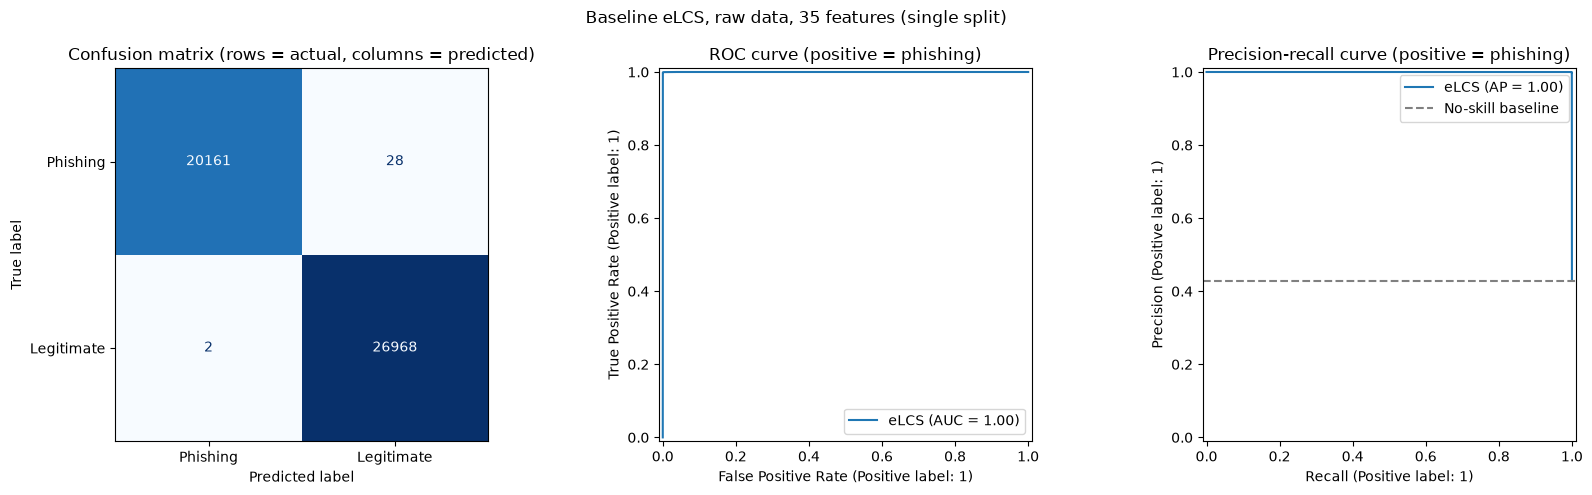

In [78]:
import os, time
import pandas as pd
from sklearn.model_selection import train_test_split
os.makedirs("results", exist_ok=True)

# Raw data, untouched: duplicates, original flags, no log1p columns
raw = pd.read_csv("/Users/christian/Uni_Files/2026/Semester 2/Data Engineering and AI/Data-Engineering-and-AI-Project-Phase-1/Phase-I/PhiUSIIL_Phishing_URL_Dataset.csv", na_values="?")      # adjust the path to match your notebook
X_raw = raw.drop(columns=["FILENAME", "URL", "Domain", "TLD", "Title", "label"])
y_raw = raw["label"]

# Map the 35 selected features onto raw column names (a "_log" feature becomes its raw original)
# `selected` must still be in memory; rerun the MI selection cell if you restarted the kernel
mapped = {c[:-4] if c.endswith("_log") else c for c in selected}
assert mapped <= set(X_raw.columns), f"Not found in the raw data: {mapped - set(X_raw.columns)}"
raw_cols = [c for c in X_raw.columns if c in mapped]                         # raw column order, as in Task 2
assert len(raw_cols) == len(selected)

# Same split settings as your Task 2 baseline
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_raw[raw_cols], y_raw, test_size=0.2, stratify=y_raw, random_state=42
)
print(Xr_train.shape, Xr_test.shape)               # expect (188636, 35) (47159, 35)

yr_train_np = yr_train.to_numpy(dtype=int)
yr_test_np  = yr_test.to_numpy(dtype=int)

model_raw35 = eLCS(learning_iterations=10000, random_state=42)               # baseline settings, unchanged

start = time.time()
model_raw35.fit(Xr_train.to_numpy(dtype=float), yr_train_np)
train_s_raw35 = time.time() - start

Xr_te_np = Xr_test.to_numpy(dtype=float)
start = time.time()
pred_raw35  = model_raw35.predict(Xr_te_np)                                  # hard labels, as before
score_raw35 = phishing_score(model_raw35, Xr_te_np, yr_test_np)              # phishing scores for the AUCs
pred_s_raw35 = time.time() - start                                           # covers predict and predict_proba

results_raw35 = evaluate(yr_test_np, pred_raw35, score_raw35)
results_raw35["Training time (s)"] = train_s_raw35
results_raw35["Prediction time (s)"] = pred_s_raw35
for k, v in results_raw35.items():
    print(f"{k:22s} {v:.4f}" if isinstance(v, float) else f"{k:22s} {v}")
print(confusion_matrix(yr_test_np, pred_raw35, labels=[0, 1]))

plot_diagnostics(yr_test_np, pred_raw35, score_raw35, "Baseline eLCS, raw data, 35 features (single split)",
                 "results/raw35_single_split_diagnostics.png")

In [79]:
from sklearn.metrics import roc_auc_score, average_precision_score
print(f"ROC-AUC: {roc_auc_score(yr_test_np == 0, score_raw35):.8f}")
print(f"PR-AUC:  {average_precision_score(yr_test_np == 0, score_raw35):.8f}")

ROC-AUC: 0.99999439
PR-AUC:  0.99999265


- Improved 

classes_ not available, phishing column chosen by orientation check: 0 (gaps: [ 0.98 -0.98])
Accuracy               0.9998
Balanced Accuracy      0.9998
Precision (Phishing)   1.0000
Recall (Phishing)      0.9996
F1 (Phishing)          0.9998
ROC-AUC                1.0000
PR-AUC                 1.0000
Missed phishing (FN)   8
False alarms (FP)      1
[[20096     8]
 [    1 26969]]


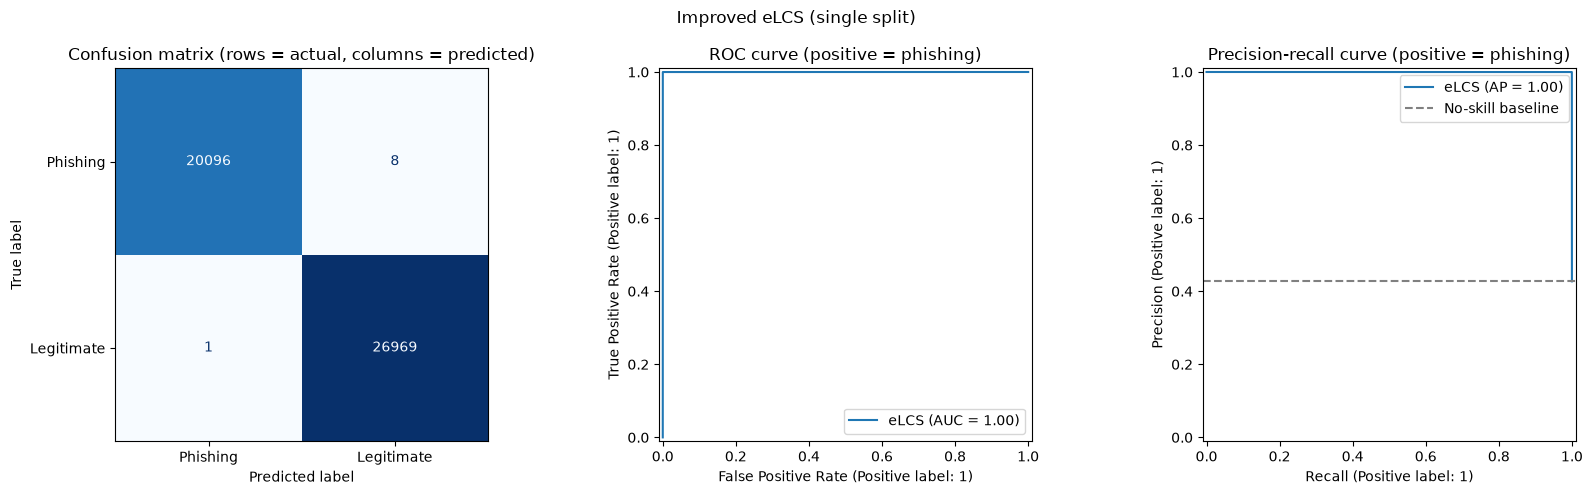

In [80]:
import os, time
os.makedirs("results", exist_ok=True)

y_train_np = y_train.to_numpy(dtype=int)
y_test_np  = y_test.to_numpy(dtype=int)

model = eLCS(learning_iterations=40000, random_state=42)
model.fit(X_train_sel.to_numpy(dtype=float), y_train_np)

X_te = X_test_sel.to_numpy(dtype=float)
pred  = model.predict(X_te)                             # hard labels, as before
score = phishing_score(model, X_te, y_test_np)          # phishing scores for the AUCs

results = evaluate(y_test_np, pred, score)
for k, v in results.items():
    print(f"{k:22s} {v:.4f}" if isinstance(v, float) else f"{k:22s} {v}")
print(confusion_matrix(y_test_np, pred, labels=[0, 1]))

plot_diagnostics(y_test_np, pred, score, "Improved eLCS (single split)", "results/single_split_diagnostics.png")

In [81]:
from sklearn.metrics import roc_auc_score, average_precision_score
print(f"ROC-AUC: {roc_auc_score(y_test_np == 0, score):.8f}")
print(f"PR-AUC:  {average_precision_score(y_test_np == 0, score):.8f}")

ROC-AUC: 0.99999950
PR-AUC:  0.99999933


## Statistical Test

In [132]:
import numpy as np
import pandas as pd
from scipy.stats import binomtest

def mcnemar_exact(y_true, pred_a, pred_b, name_a="A", name_b="B"):
    y_true, pred_a, pred_b = (np.asarray(x) for x in (y_true, pred_a, pred_b))
    assert len(y_true) == len(pred_a) == len(pred_b), "Predictions must cover the same rows"
    assert (pred_a >= 0).all() and (pred_b >= 0).all(), "Some rows were never predicted (-1 placeholder left)"

    a_ok, b_ok = (pred_a == y_true), (pred_b == y_true)
    both_right = int((a_ok & b_ok).sum())
    a_only     = int((a_ok & ~b_ok).sum())      # A right, B wrong
    b_only     = int((~a_ok & b_ok).sum())      # A wrong, B right
    both_wrong = int((~a_ok & ~b_ok).sum())
    n_disc = a_only + b_only
    p = binomtest(a_only, n_disc, 0.5).pvalue if n_disc > 0 else 1.0

    table = pd.DataFrame(
        [[both_right, a_only], [b_only, both_wrong]],
        index=[f"{name_a} right", f"{name_a} wrong"],
        columns=[f"{name_b} right", f"{name_b} wrong"],
    )
    print(table)
    print(f"Discordant rows: {n_disc} | {name_a} wrong only: {b_only} | {name_b} wrong only: {a_only}")
    print(f"Errors: {name_a} = {int((~a_ok).sum())}, {name_b} = {int((~b_ok).sum())}")
    print(f"Exact McNemar p-value: {p:.4g}")
    return {"a_only": a_only, "b_only": b_only, "p": p}

def paired_bootstrap(y_true, pred_a, pred_b, n_boot=10000, seed=42):
    """95% interval for (errors of A minus errors of B), resampling rows."""
    y_true, pred_a, pred_b = (np.asarray(x) for x in (y_true, pred_a, pred_b))
    err_a, err_b = (pred_a != y_true).astype(int), (pred_b != y_true).astype(int)
    rng = np.random.default_rng(seed)
    n = len(y_true)
    diffs = np.array([err_a[i].sum() - err_b[i].sum() for i in (rng.integers(0, n, n) for _ in range(n_boot))])
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    print(f"Errors A minus errors B: observed {err_a.sum() - err_b.sum()}, 95% bootstrap interval [{lo:.0f}, {hi:.0f}]")

In [86]:
from sklearn.metrics import confusion_matrix

print(len(y_test_np), len(pred_all_50), len(pred))                  # all should be 47074
print(confusion_matrix(y_test_np, pred_all_50, labels=[0, 1]))      # expect [[20074 30], [23 26947]]
print(confusion_matrix(y_test_np, pred, labels=[0, 1]))           # expect [[20096 8], [1 26969]]

47074 47074 47074
[[20074    30]
 [   23 26947]]
[[20096     8]
 [    1 26969]]


In [87]:
res_single = mcnemar_exact(y_test_np, pred_all_50, pred, name_a="Baseline", name_b="Improved")
paired_bootstrap(y_test_np, pred_all_50, pred)

# Phishing rows only: tests the difference in missed phishing specifically
phish = (y_test_np == 0)
mcnemar_exact(y_test_np[phish], pred_all_50[phish], pred[phish], name_a="Baseline", name_b="Improved")

                Improved right  Improved wrong
Baseline right           47019               2
Baseline wrong              46               7
Discordant rows: 48 | Baseline wrong only: 46 | Improved wrong only: 2
Errors: Baseline = 53, Improved = 9
Exact McNemar p-value: 8.363e-12
Errors A minus errors B: observed 44, 95% bootstrap interval [31, 58]
                Improved right  Improved wrong
Baseline right           20073               1
Baseline wrong              23               7
Discordant rows: 24 | Baseline wrong only: 23 | Improved wrong only: 1
Errors: Baseline = 30, Improved = 8
Exact McNemar p-value: 2.98e-06


{'a_only': 1, 'b_only': 23, 'p': np.float64(2.9802322387695312e-06)}

# Task 6: Model Comparison

- Original LCS on the raw or minimally processed dataset.

In [158]:
import os, time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from skeLCS import eLCS

os.makedirs("results", exist_ok=True)
task6 = {}

def run_system(name, X_tr, y_tr, X_te, y_te, iterations, seed=42):
    y_tr_np = np.asarray(y_tr, dtype=int)
    y_te_np = np.asarray(y_te, dtype=int)
    assert len(X_tr) == len(y_tr_np), f"{name}: {len(X_tr)} training rows but {len(y_tr_np)} labels"
    assert len(X_te) == len(y_te_np), f"{name}: {len(X_te)} test rows but {len(y_te_np)} labels"
    assert list(X_tr.columns) == list(X_te.columns), f"{name}: train and test columns differ"

    model = eLCS(learning_iterations=iterations, random_state=seed)
    t0 = time.time()
    model.fit(X_tr.to_numpy(dtype=float), y_tr_np)
    train_s = time.time() - t0

    X_te_np = X_te.to_numpy(dtype=float)
    t0 = time.time()
    pred = model.predict(X_te_np)                              # timed on its own, comparable with earlier runs
    pred_s = time.time() - t0
    score = phishing_score(model, X_te_np, y_te_np)            # from cell 45, used for the AUCs

    res = evaluate(y_te_np, pred, score)                       # from cell 45, phishing (0) is the positive class
    res.update({"Features": X_tr.shape[1], "Iterations": iterations, "Test rows": len(X_te),
                "Training time (s)": train_s, "Prediction time (s)": pred_s})

    print(f"\n[{name}] {X_tr.shape[1]} features, {iterations:,} iterations, {len(X_te):,} test rows")
    for k, v in res.items():
        if k in ("ROC-AUC", "PR-AUC"):
            print(f"{k:22s} {v:.8f}")                          # more decimals, since AUCs sit near 1
        elif isinstance(v, float):
            print(f"{k:22s} {v:.4f}")
        else:
            print(f"{k:22s} {v}")
    print(confusion_matrix(y_te_np, pred, labels=[0, 1]))

    return {"model": model, "pred": pred, "score": score, "y_test": y_te_np,
            "features": X_tr.columns.tolist(), "results": res}

In [137]:
X_raw_min = data.drop(columns=dropped_features)        # only identifier, text, and label columns removed
y_raw_min = data["label"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_raw_min, y_raw_min, test_size=0.2, stratify=y_raw_min, random_state=42
)
assert Xr_train.shape == (188636, 50) and Xr_test.shape == (47159, 50)

task6["raw_baseline"] = run_system("raw_baseline", Xr_train, yr_train, Xr_test, yr_test, iterations=10000)


classes_ not available, phishing column chosen by orientation check: 0 (gaps: [ 0.971 -0.971])

[raw_baseline] 50 features, 10,000 iterations, 47,159 test rows
Accuracy               0.9990
Balanced Accuracy      0.9989
Precision (Phishing)   1.0000
Recall (Phishing)      0.9978
F1 (Phishing)          0.9989
ROC-AUC                0.99998844
PR-AUC                 0.99998580
Missed phishing (FN)   45
False alarms (FP)      0
Features               50
Iterations             10000
Test rows              47159
Training time (s)      19.0966
Prediction time (s)    69.0810
[[20144    45]
 [    0 26970]]


- Original LCS on the preprocessed dataset

In [138]:
# Rebuild the preprocessed labels from drop_url_dup, using the same rows as X_train_pr and X_test_pr
y_train_pre = drop_url_dup.loc[X_train_pr.index, "label"].astype(int)
y_test_pre  = drop_url_dup.loc[X_test_pr.index,  "label"].astype(int)

assert X_train_pr.shape == (188296, 50) and X_test_pr.shape == (47074, 50)
assert y_train_pre.value_counts().to_dict() == {1: 107880, 0: 80416}

task6["pre_baseline"] = run_system("pre_baseline", X_train_pr, y_train_pre, X_test_pr, y_test_pre, iterations=10000)

classes_ not available, phishing column chosen by orientation check: 0 (gaps: [ 0.978 -0.978])

[pre_baseline] 50 features, 10,000 iterations, 47,074 test rows
Accuracy               0.9989
Balanced Accuracy      0.9988
Precision (Phishing)   0.9989
Recall (Phishing)      0.9985
F1 (Phishing)          0.9987
ROC-AUC                0.99988017
PR-AUC                 0.99988909
Missed phishing (FN)   30
False alarms (FP)      23
Features               50
Iterations             10000
Test rows              47074
Training time (s)      19.1861
Prediction time (s)    64.0925
[[20074    30]
 [   23 26947]]


- Improved LCS-based system on the preprocessed and feature-engineered dataset

In [139]:
assert X_train_sel.index.equals(X_train_pr.index) and X_test_sel.index.equals(X_test_pr.index)
assert X_train_sel.shape[1] == len(selected)               # 35 with your 0.05 threshold

task6["improved"] = run_system("improved", X_train_sel, y_train_pre, X_test_sel, y_test_pre, iterations=40000)

classes_ not available, phishing column chosen by orientation check: 0 (gaps: [ 0.98 -0.98])

[improved] 35 features, 40,000 iterations, 47,074 test rows
Accuracy               0.9998
Balanced Accuracy      0.9998
Precision (Phishing)   1.0000
Recall (Phishing)      0.9996
F1 (Phishing)          0.9998
ROC-AUC                0.99999950
PR-AUC                 0.99999933
Missed phishing (FN)   8
False alarms (FP)      1
Features               35
Iterations             40000
Test rows              47074
Training time (s)      34.4288
Prediction time (s)    65.0529
[[20096     8]
 [    1 26969]]


## Conventional Models


In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

def run_conventional(name, model, X_tr, y_tr, X_te, y_te):
    y_tr_np = np.asarray(y_tr, dtype=int)
    y_te_np = np.asarray(y_te, dtype=int)
    assert len(X_tr) == len(y_tr_np), f"{name}: {len(X_tr)} training rows but {len(y_tr_np)} labels"
    assert len(X_te) == len(y_te_np), f"{name}: {len(X_te)} test rows but {len(y_te_np)} labels"
    assert list(X_tr.columns) == list(X_te.columns), f"{name}: train and test columns differ"

    t0 = time.time()
    model.fit(X_tr, y_tr_np)
    train_s = time.time() - t0

    t0 = time.time()
    pred = model.predict(X_te)
    pred_s = time.time() - t0
    score = phishing_score(model, X_te, y_te_np)               # from cell 45, uses model.classes_

    res = evaluate(y_te_np, pred, score)                       # from cell 45, phishing (0) is the positive class
    res.update({"Features": X_tr.shape[1], "Iterations": np.nan, "Test rows": len(X_te),
                "Training time (s)": train_s, "Prediction time (s)": pred_s})

    print(f"\n[{name}] {X_tr.shape[1]} features, {len(X_te):,} test rows")
    for k, v in res.items():
        if k in ("ROC-AUC", "PR-AUC"):
            print(f"{k:22s} {v:.8f}")
        elif k == "Iterations":
            continue                                           # not applicable to these models
        elif isinstance(v, float):
            print(f"{k:22s} {v:.4f}")
        else:
            print(f"{k:22s} {v}")
    print(confusion_matrix(y_te_np, pred, labels=[0, 1]))

    return {"model": model, "pred": pred, "score": score, "y_test": y_te_np,
            "features": X_tr.columns.tolist(), "results": res}

# Same scaling decision as before: binary flags stay as they are, non-binary features are scaled
lr_binary = [c for c in X_train_pr.columns if X_train_pr[c].nunique() <= 2]
lr_scaled = [c for c in X_train_pr.columns if c not in lr_binary]
print(f"{len(lr_binary)} binary, {len(lr_scaled)} scaled")      # expect 19 and 31

conventional = {
    "random_forest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    "decision_tree": DecisionTreeClassifier(random_state=42),
    "logistic_regression": Pipeline([
        ("scale", ColumnTransformer([("scale", StandardScaler(), lr_scaled)], remainder="passthrough")),
        ("clf", LogisticRegression(max_iter=2000, random_state=42)),     # scaling is fitted on training rows only
    ]),
}

for name, model in conventional.items():
    task6[name] = run_conventional(name, model, X_train_pr, y_train_pre, X_test_pr, y_test_pre)

19 binary, 31 scaled

[random_forest] 50 features, 47,074 test rows
Accuracy               1.0000
Balanced Accuracy      1.0000
Precision (Phishing)   1.0000
Recall (Phishing)      1.0000
F1 (Phishing)          1.0000
ROC-AUC                1.00000000
PR-AUC                 1.00000000
Missed phishing (FN)   0
False alarms (FP)      0
Features               50
Test rows              47074
Training time (s)      3.2413
Prediction time (s)    0.0611
[[20104     0]
 [    0 26970]]

[decision_tree] 50 features, 47,074 test rows
Accuracy               1.0000
Balanced Accuracy      1.0000
Precision (Phishing)   1.0000
Recall (Phishing)      1.0000
F1 (Phishing)          1.0000
ROC-AUC                1.00000000
PR-AUC                 1.00000000
Missed phishing (FN)   0
False alarms (FP)      0
Features               50
Test rows              47074
Training time (s)      0.3072
Prediction time (s)    0.0028
[[20104     0]
 [    0 26970]]

[logistic_regression] 50 features, 47,074 test rows
Accu

In [150]:
# 1. Drop the leaking feature from both your training and testing sets immediately
X_train_sel_clean = X_train_sel.drop(columns=['URLSimilarityIndex'])
X_test_sel_clean = X_test_sel.drop(columns=['URLSimilarityIndex'])

# 2. Assertions updated to account for 34 clean features instead of 35
assert X_train_sel_clean.index.equals(X_train_pr.index) and X_test_sel_clean.index.equals(X_test_pr.index)
assert X_train_sel_clean.shape[1] == len(selected) - 1                       

# 3. Calculate scaling rules using the clean data (prevents the pipeline ValueError)
sel_binary = [c for c in X_train_sel_clean.columns if X_train_sel_clean[c].nunique() <= 2]
sel_scaled = [c for c in X_train_sel_clean.columns if c not in sel_binary]
print(f"{len(sel_binary)} binary, {len(sel_scaled)} scaled")      # Should print: 11 binary, 23 scaled

# 4. Define conventional dictionary using the clean, updated scaled features list
conventional_sel = {
    "random_forest_sel": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    "decision_tree_sel": DecisionTreeClassifier(random_state=42),
    "logistic_regression_sel": Pipeline([
        ("scale", ColumnTransformer([("scale", StandardScaler(), sel_scaled)], remainder="passthrough")),
        ("clf", LogisticRegression(max_iter=2000, random_state=42)),     
    ]),
}

# 5. Run the training loop cleanly
for name, model in conventional_sel.items():
    task6[name] = run_conventional(name, model, X_train_sel_clean, y_train_pre, X_test_sel_clean, y_test_pre)


11 binary, 23 scaled

[random_forest_sel] 34 features, 47,074 test rows
Accuracy               0.9999
Balanced Accuracy      0.9999
Precision (Phishing)   1.0000
Recall (Phishing)      0.9998
F1 (Phishing)          0.9999
ROC-AUC                0.99999994
PR-AUC                 0.99999991
Missed phishing (FN)   4
False alarms (FP)      0
Features               34
Test rows              47074
Training time (s)      4.9197
Prediction time (s)    0.0648
[[20100     4]
 [    0 26970]]

[decision_tree_sel] 34 features, 47,074 test rows
Accuracy               0.9990
Balanced Accuracy      0.9990
Precision (Phishing)   0.9987
Recall (Phishing)      0.9991
F1 (Phishing)          0.9989
ROC-AUC                0.99902690
PR-AUC                 0.99811732
Missed phishing (FN)   19
False alarms (FP)      27
Features               34
Test rows              47074
Training time (s)      1.7159
Prediction time (s)    0.0031
[[20085    19]
 [   27 26943]]

[logistic_regression_sel] 34 features, 47,074 

In [151]:
import pandas as pd
import numpy as np

def check_feature_leakage(model, X_data, threshold=0.70):
    """
    Ranks feature importances directly from a Pandas DataFrame or list of names.
    """
    # Automatically extract column names if a DataFrame is provided
    if isinstance(X_data, pd.DataFrame):
        feature_names = X_data.columns.tolist()
    else:
        feature_names = list(X_data)
        
    # 1. Extract and sort the feature importances
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    # 2. Create a clean DataFrame for visualization
    df_importance = pd.DataFrame({
        'Feature': [feature_names[i] for i in indices],
        'Importance_Score': [importances[i] for i in indices]
    })
    
    print("=== TOP 10 MOST IMPORTANT FEATURES ===")
    print(df_importance.head(10).to_string(index=False))
    print("=" * 38)
    
    # 3. Check for leakage red flags using explicit coordinate indexing
    top_feature = df_importance.iloc[0]['Feature']
    top_score = df_importance.iloc[0]['Importance_Score']
    
    if top_score >= threshold:
        print(f"\n🚨 WARNING: Potential Data Leakage Detected!")
        print(f"The feature '{top_feature}' holds {top_score*100:.1f}% of the model's total decision weight.")
        print("A single feature should rarely dominate a model this heavily. Double-check this column.")
    else:
        print("\n✅ Clean Bill of Health: No single feature completely dominates the decisions.")

# Run the function on your specific dictionary model output:
# If the key is 'model', extract it first:
trained_tree = task6["decision_tree_sel"]["model"] 

check_feature_leakage(trained_tree, X_train_sel)



=== TOP 10 MOST IMPORTANT FEATURES ===
              Feature  Importance_Score
     NoOfEmptyRef_log          0.849173
           NoOfJS_log          0.062591
      DegitRatioInURL          0.028125
SpacialCharRatioInURL          0.015508
        URLLength_log          0.011516
          URLCharProb          0.009627
           NoOfiFrame          0.008218
LargestLineLength_log          0.004704
         IsResponsive          0.002812
     NoOfLettersInURL          0.001627

🚨 WARNING: Potential Data Leakage Detected!
The feature 'NoOfEmptyRef_log' holds 84.9% of the model's total decision weight.
A single feature should rarely dominate a model this heavily. Double-check this column.


# Task 7: Interpretation of results

In [160]:
import pandas as pd

improved_model = task6["improved"]["model"]          # the improved eLCS trained in the cell above

# Header names must be the training columns in the same order, otherwise rules get the wrong feature names
assert list(X_test_sel_clean.columns) == task6["improved"]["features"], "Columns don't match the model's training features"

# Export the rules from the improved LCS model
improved_model.export_final_rule_population(X_test_sel_clean.columns, 'Class', 'improved_lcs_rules.csv', DCAL=True)

rules_df = pd.read_csv('improved_lcs_rules.csv')
print(f"Total rules in population: {len(rules_df)}")
rules_df.head(10)

Total rules in population: 906


,Specified Values,Specified Attribute Names,Class,Fitness,Accuracy,Numerosity,Avg Match Set Size,TimeStamp GA,Iteration Initialized,Specificity,Deletion Probability,Correct Count,Match Count
0,"[-22.04,50.04], 0.0, [-1655.075,1719.075], [-3...","DomainLength, NoOfSubDomain, NoOfLettersInURL,...",0.0,1.0,1.0,1,68.957760,39718,29,0.500000,0.000433,10,10
1,"[4.630000000000001,35.37], [0.81,1.19], [0.554...","DomainLength, CharContinuationRate, TLDLegitim...",1.0,0.1,1.0,1,1.864000,82,82,0.441176,0.000012,0,0
2,"[0.6799999999999999,1.32], [0.0541909155,0.082...","CharContinuationRate, URLCharProb, NoOfSubDoma...",1.0,0.1,1.0,1,1.250000,104,104,0.470588,0.000008,0,0
3,"[25.14,90.86], [-0.1173234975,0.1179846975], [...","DomainLength, TLDLegitimateProb, URLCharProb, ...",0.0,1.0,1.0,1,18.000000,31429,181,0.558824,0.000113,3,3
4,"[0.675,1.325], [0.43139835749999994,0.61441584...","CharContinuationRate, TLDLegitimateProb, NoOfL...",1.0,1.0,1.0,1,1.000000,348,348,0.558824,0.000006,1,1
5,"[-0.0949214105,0.1717612105], [0.046756985,0.0...","TLDLegitimateProb, URLCharProb, NoOfDegitsInUR...",1.0,0.1,1.0,1,5.000000,394,394,0.588235,0.000031,0,0
6,"[-528.0250000000001,578.0250000000001], [-185....","NoOfDegitsInURL, NoOfOtherSpecialCharsInURL, S...",0.0,1.0,1.0,2,96.566245,39928,7353,0.205882,0.001213,231,231
7,"[-318.76,324.76], [-75.345,79.345], 0.0, [-2.7...","NoOfDegitsInURL, NoOfOtherSpecialCharsInURL, H...",0.0,1.0,1.0,1,192.299162,39993,16786,0.176471,0.001188,7287,7287
8,"[-14.030000000000001,40.03], [-0.0210259411688...","DomainLength, URLCharProb, NoOfOtherSpecialCha...",1.0,1.0,1.0,3,109.727998,39749,18817,0.411765,0.002067,77,77
9,"[0.028062795499999998,0.05154180377699835], 1....","URLCharProb, NoOfSubDomain, NoOfLettersInURL, ...",0.0,1.0,1.0,1,97.818401,39816,21121,0.411765,0.000614,18,18


In [163]:
# Rule 7 (phishing), exact conditions from improved_lcs_rules.csv
# Training: 7,287 matches, 7,287 correct (accuracy 1.000)
def rule_7(X):
    return (
        (X["NoOfDegitsInURL"] > -318.76) & (X["NoOfDegitsInURL"] < 324.76) &                        # very wide, almost every URL fits
        (X["NoOfOtherSpecialCharsInURL"] > -75.345) & (X["NoOfOtherSpecialCharsInURL"] < 79.345) &  # very wide, almost every URL fits
        (X["HasSocialNet"] == 0) &                                                                   # no social media links
        (X["LineOfCode_log"] > -2.71001516243399) & (X["LineOfCode_log"] < 4.550180916229388) &      # fewer than about 94 lines of code
        (X["NoOfImage_log"] > -2.1457260568569807) & (X["NoOfImage_log"] < 1.638034313125535) &      # 4 images or fewer
        (X["NoOfCSS_log"] > -3.932358597221108) & (X["NoOfCSS_log"] < 3.932358597221108)             # fewer than about 50 CSS files
    )

# Apply Rule 7 to the test set
matched = rule_7(X_test_sel)
print("Test URLs matched by Rule 7:", int(matched.sum()))
print("Of those, actually phishing:", int((y_test_pre[matched] == 0).sum()))
print("Rule 7 accuracy on the test set:", round((y_test_pre[matched] == 0).mean(), 4))

Test URLs matched by Rule 7: 15095
Of those, actually phishing: 15095
Rule 7 accuracy on the test set: 1.0


In [167]:
# Rule 19 (legitimate), exact conditions from improved_lcs_rules.csv
# Training: 6,062 matches, 6,058 correct (accuracy 0.999)
def rule_19(X):
    return (
        (X["DomainLength"] > 5.98) & (X["DomainLength"] < 50.33) &                                                         # domain of 6 to 50 characters
        (X["NoOfSubDomain"] == 1) &                                                                                       # exactly one subdomain
        (X["NoOfDegitsInURL"] > -623.41) & (X["NoOfDegitsInURL"] < 898.5964547215442) &                                   # very wide, almost every URL fits
        (X["SpacialCharRatioInURL"] > -0.051295000000000014) & (X["SpacialCharRatioInURL"] < 0.13529500000000003) &       # few special characters
        (X["IsHTTPS"] == 1) &                                                                                             # uses HTTPS
        (X["NoOfiFrame"] > -504.63) & (X["NoOfiFrame"] < 514.64) &                                                        # very wide, almost every URL fits
        (X["LargestLineLength_log"] > 4.081510589787327) & (X["LargestLineLength_log"] < 13.774232089941453) &            # longest code line of about 58 characters or more
        (X["NoOfSelfRef_log"] > 1.8819626859433654) & (X["NoOfSelfRef_log"] < 7.473278518347058)                          # about 6 to 1,760 links to its own site
    )


matched = rule_19(X_test_sel)
print("Test URLs matched by Rule 19:", int(matched.sum()))
print("Of those, actually phishing:", int((y_test_pre[matched] == 1).sum()))
print("Rule 19 accuracy on the test set:", round((y_test_pre[matched] == 1).mean(), 4))

Test URLs matched by Rule 19: 20768
Of those, actually phishing: 20743
Rule 19 accuracy on the test set: 0.9988


In [168]:
# Rule 23 (legitimate), exact conditions from improved_lcs_rules.csv
# Training: 5,580 matches, 5,566 correct (accuracy 0.997)
def rule_23(X):
    return (
        (X["CharContinuationRate"] > 0.5083333329999999) & (X["CharContinuationRate"] < 1.158333333) &   # characters run in fairly long unbroken sequences
        (X["NoOfLettersInURL"] > -1051.155) & (X["NoOfLettersInURL"] < 1711.075) &                       # very wide, almost every URL fits
        (X["IsHTTPS"] == 1) &                                                                            # uses HTTPS
        (X["NoOfiFrame"] > -448.56000000000006) & (X["NoOfiFrame"] < 428.53000000000003) &               # very wide, almost every URL fits
        (X["HasSocialNet"] == 1)                                                                         # has social media links
    )

matched = rule_23(X_test_sel)
print("Test URLs matched by Rule 23:", int(matched.sum()))
print("Of those, actually phishing:", int((y_test_pre[matched] == 1).sum()))
print("Rule 23 accuracy on the test set:", round((y_test_pre[matched] == 1).mean(), 4))

Test URLs matched by Rule 23: 21136
Of those, actually phishing: 21089
Rule 23 accuracy on the test set: 0.9978
